# Data Cleaning

In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_excel("Health_survey.xlsx")

In [3]:
print("=> Original dataset:")
df.head()

=> Original dataset:


,Timestamp,How many times do you eat vegetables in a week?\n(Include meals that contain vegetables)\n,"How many times do you eat fast food (e.g., burgers, fried chicken, instant noodles) in a week? \n","On average, how many liters of water do you drink per day? \nAnswer: ______ liters per day",How many meals do you usually eat per day?,How many days per week do you exercise? \n,"Dou you think you healthy or not ?\n(if healthy answer yes , if unhealthy answer no)"
0,2026-03-24 14:29:41.169,6,2,3.0,2,5,Yes
1,2026-03-24 14:36:16.335,3,2,1.5,2,2,No
2,2026-03-24 14:36:26.953,4,2,2.0,3,2,No
3,2026-03-24 14:36:49.994,7,2,2.0,2,1,Yes
4,2026-03-24 14:37:54.135,4,4,1.5,4,5,Yes


In [4]:
df.shape

(60, 7)

In [5]:
df.columns

Index(['Timestamp',
       'How many times do you eat vegetables in a week?\n(Include meals that contain vegetables)\n',
       'How many times do you eat fast food (e.g., burgers, fried chicken, instant noodles) in a week?  \n',
       'On average, how many liters of water do you drink per day?  \nAnswer: ______ liters per day',
       'How many meals do you usually eat per day?  ',
       'How many days per week do you exercise?  \n',
       'Dou you think you healthy or not ?\n(if healthy answer yes , if unhealthy answer no)'],
      dtype='object')

In [6]:
#rename the columns 
df.columns = [
    "timestamp",
    "vegetables",
    "fast_food",
    "water",
    "meals",
    "exercise",
    "healthy"
]

print("=> Rename columns:")
df.columns

=> Rename columns:


Index(['timestamp', 'vegetables', 'fast_food', 'water', 'meals', 'exercise',
       'healthy'],
      dtype='object')

In [7]:
#drop timestamp columns 
df = df.drop(columns=["timestamp"])

In [8]:
#check the data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   vegetables  60 non-null     int64  
 1   fast_food   60 non-null     int64  
 2   water       60 non-null     float64
 3   meals       60 non-null     int64  
 4   exercise    60 non-null     int64  
 5   healthy     60 non-null     object 
dtypes: float64(1), int64(4), object(1)
memory usage: 2.9+ KB


In [9]:
# Remove whitespace & standardize target
df["healthy"] = df["healthy"].astype(str).str.strip().str.lower()

# Convert yes/no → 1/0
df["healthy"] = df["healthy"].map({"yes": 1, "no": 0})

In [10]:
# Convert all feature columns to numeric
features = ["vegetables", "fast_food", "water", "meals", "exercise"]

for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [11]:
print("=> Missing value in this dataset:")
df.isnull().sum()

=> Missing value in this dataset:


vegetables    0
fast_food     0
water         0
meals         0
exercise      0
healthy       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(2)

In [13]:
df = df[
    (df["vegetables"] >= 0) &
    (df["fast_food"] >= 0) &
    (df["water"] >= 0) &
    (df["meals"] > 0) &
    (df["exercise"] >= 0)
]

In [14]:
# Final check
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   vegetables  60 non-null     int64  
 1   fast_food   60 non-null     int64  
 2   water       60 non-null     float64
 3   meals       60 non-null     int64  
 4   exercise    60 non-null     int64  
 5   healthy     60 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 2.9 KB
(60, 6)


# EDA

In [15]:
df.describe()

,vegetables,fast_food,water,meals,exercise,healthy
count,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000
mean,4.700000,3.183333,2.258333,3.40000,3.866667,0.616667
std,1.834694,1.751432,0.949985,1.02841,2.288265,0.490301
min,1.000000,1.000000,0.500000,1.00000,0.000000,0.000000
25%,3.000000,2.000000,1.500000,3.00000,2.000000,0.000000
50%,5.000000,3.000000,2.000000,3.00000,5.000000,1.000000
75%,6.000000,5.000000,3.000000,4.00000,6.000000,1.000000
max,7.000000,7.000000,4.000000,5.00000,7.000000,1.000000


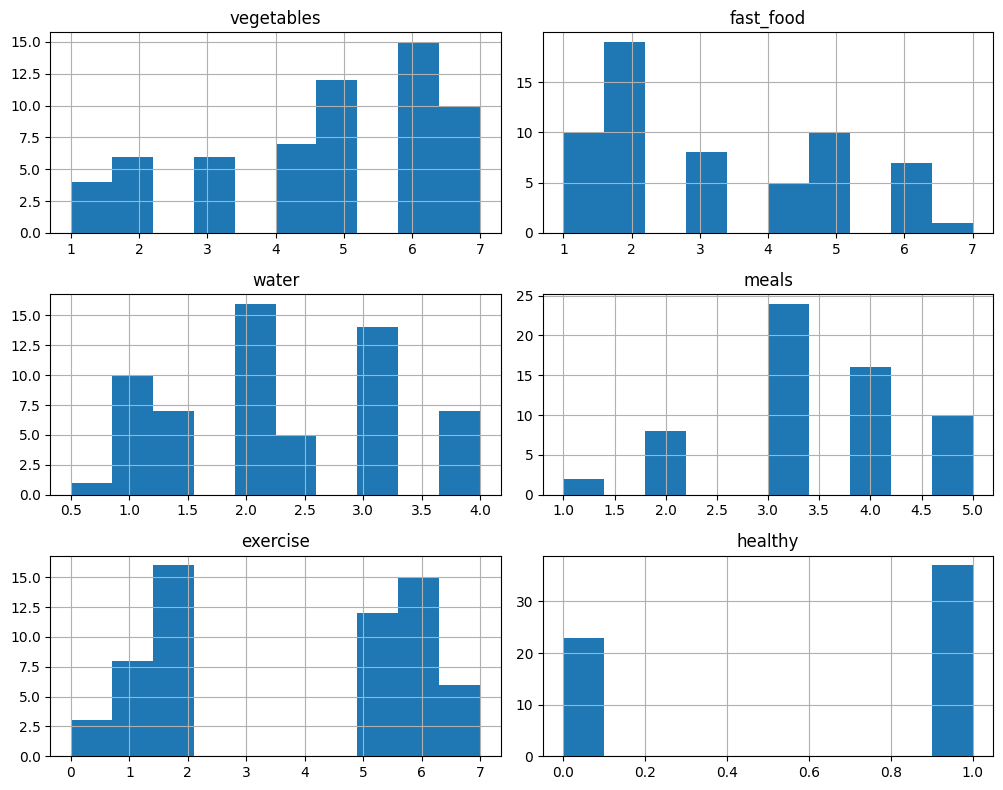

In [16]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

healthy
1    37
0    23
Name: count, dtype: int64


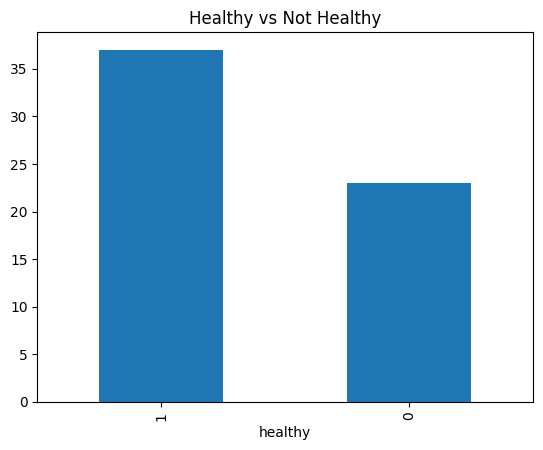

In [17]:
print(df["healthy"].value_counts())

df["healthy"].value_counts().plot(kind="bar")
plt.title("Healthy vs Not Healthy")
plt.show()

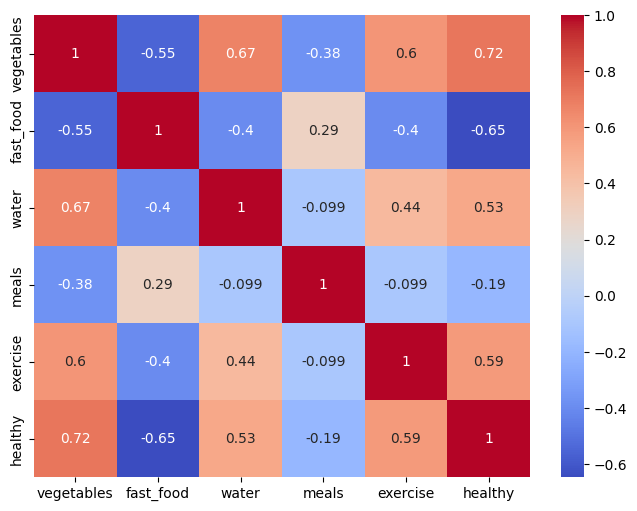

In [18]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

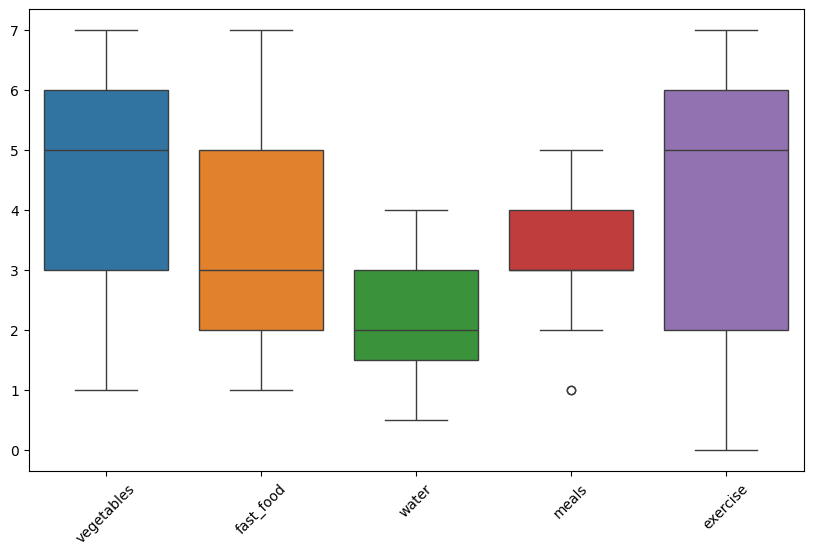

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[features])
plt.xticks(rotation=45)
plt.show()

# Logictic regression model

In [20]:
#select features
X = df[["vegetables", "fast_food", "exercise", "water", "meals"]].values
y = df["healthy"].values

In [21]:
#train-test split (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

In [22]:
# Use only training data mean/std
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# avoid division by zero
std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


In [23]:
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [24]:
#sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [25]:
#hypothesis 
def hypothesis(X, theta):
    return sigmoid(X @ theta)

In [26]:
# cost function
def compute_cost(X, y, theta):
    m = len(y)
    h = hypothesis(X, theta)
    eps = 1e-8
    cost = -(1 / m) * np.sum(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
    return cost

In [27]:
# gradient descent
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        h = hypothesis(X, theta)
        gradient = (1 / m) * (X.T @ (h - y))
        theta = theta - learning_rate * gradient

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history

In [28]:
#initial theta 
theta = np.zeros(X_train.shape[1])

In [29]:
#training
theta, cost_history = gradient_descent(
    X_train,
    y_train,
    theta,
    learning_rate=0.01,
    iterations=1000
)

print("Optimized theta:", theta)

Optimized theta: [ 0.66958217  1.02563463 -0.68080489  0.60519198  0.38582862  0.23215029]


In [30]:
#  Prediction function
def predict(X, theta):
    probs = hypothesis(X, theta)
    return (probs >= 0.5).astype(int)

In [31]:
# Predict on test set
y_pred = predict(X_test, theta)

print("Predicted:", y_pred)
print("Actual:", y_test)

Predicted: [0 1 1 1 0 1 1 1 0 1 0 1]
Actual: [0 1 1 0 0 1 1 0 0 1 0 1]


In [32]:
# Accuracy
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [33]:
# Confusion Matrix
tp = np.sum((y_test == 1) & (y_pred == 1))
tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))

print("Confusion Matrix:")
print([[tn, fp],
       [fn, tp]])

print("TP =", tp)
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)

Confusion Matrix:
[[np.int64(4), np.int64(2)], [np.int64(0), np.int64(6)]]
TP = 6
TN = 4
FP = 2
FN = 0


In [34]:
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.75
Recall: 1.0
F1-score: 0.8571428571428571


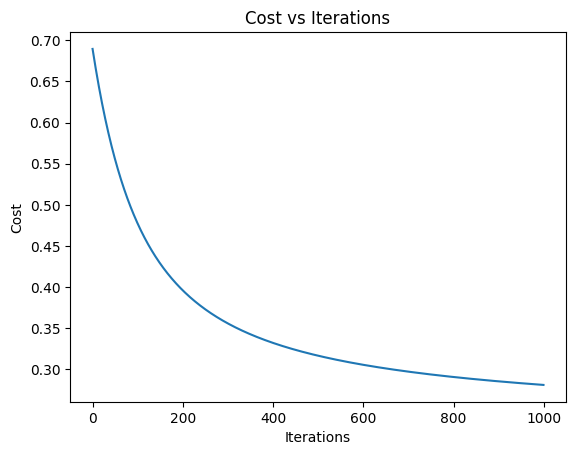

In [35]:
# Plot cost history

import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

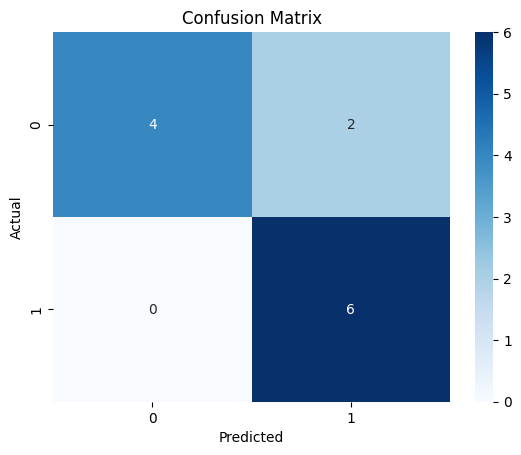

In [36]:
import seaborn as sns

cm = [[tn, fp],
      [fn, tp]]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

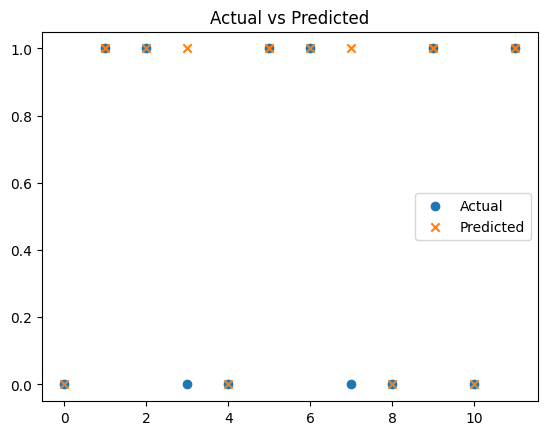

In [37]:
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", marker='x')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

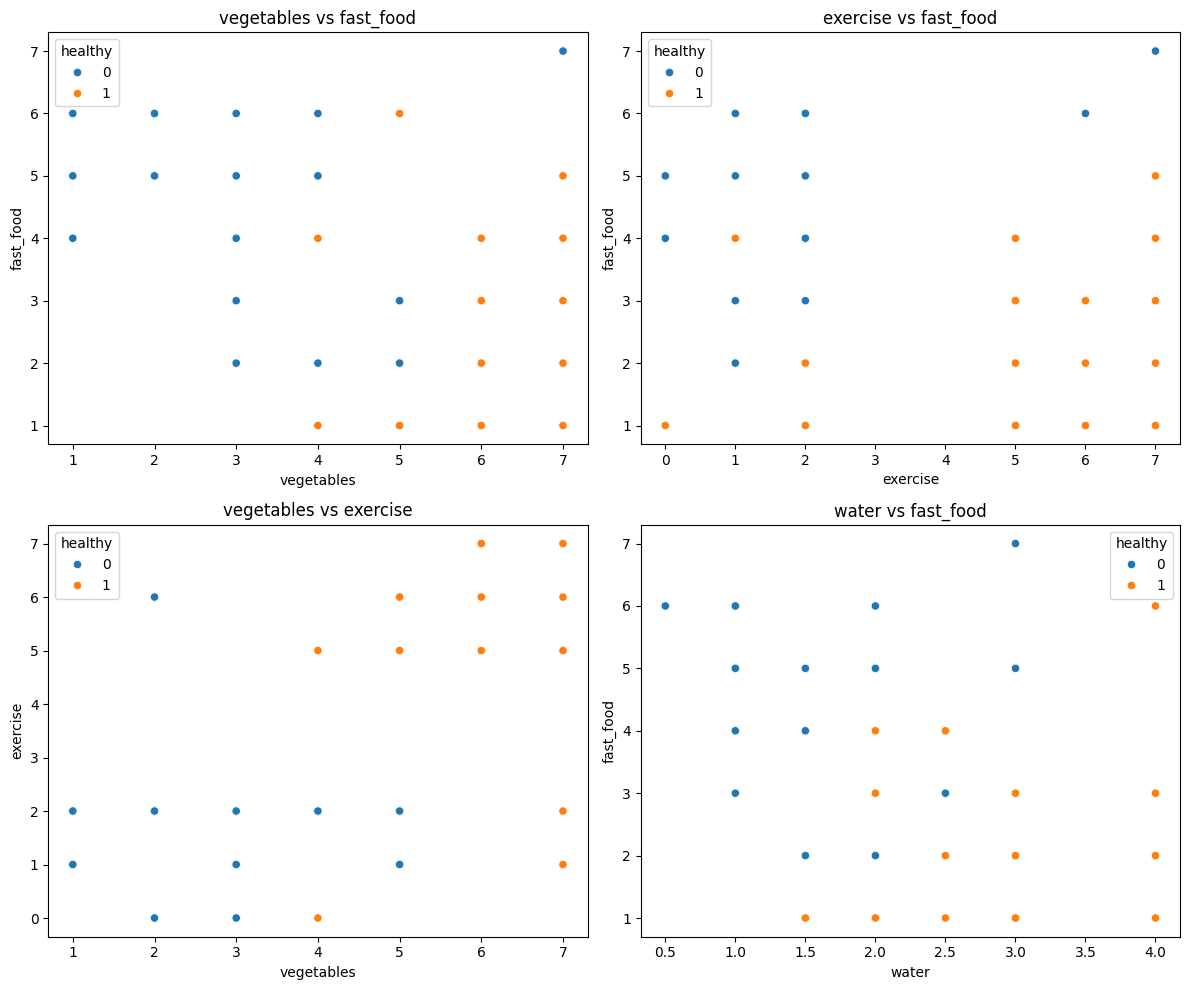

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

pairs = [
    ("vegetables", "fast_food"),
    ("exercise", "fast_food"),
    ("vegetables", "exercise"),
    ("water", "fast_food")
]

# Create subplot grid (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten axes for easy loop
axes = axes.flatten()

for i, (x, y) in enumerate(pairs):
    sns.scatterplot(
        x=x,
        y=y,
        hue="healthy",
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

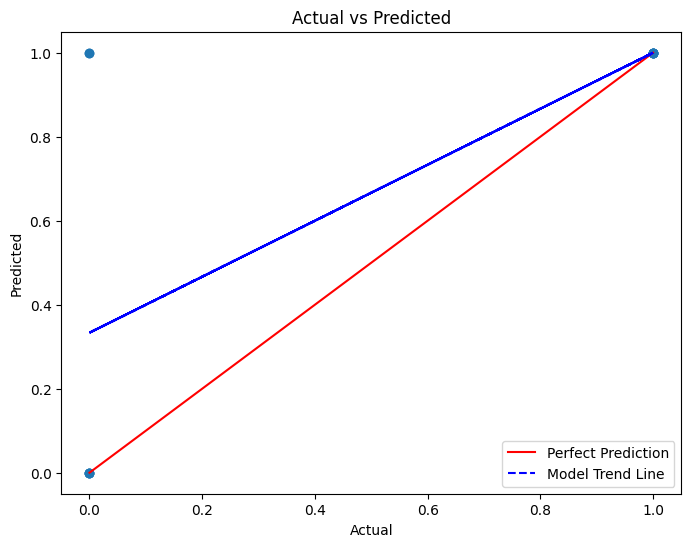

In [ ]:
        # Convert to numpy arrays (if not already)
y_test = np.array(y_test)
y_pred = np.array(y_pred)

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([0,1], [0,1], 'r-', label="Perfect Prediction")

# Fit trend line
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b, 'b--', label="Model Trend Line")

# Labels
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.legend()
plt.show()